In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [6]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

# if the API does a "ReadTimeout", it means the API was asleep and if you call it a minute later it will be back online
# I will put it behind an always-on API when more people are paying for it. Currently, I am the only one who seems to be
# using it, so I do not mind. :)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [7]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [8]:
question = 'what has been seen in the last 24 hours?'
#question = 'what has happened in Indiana in July 2026?'

answer = ask_api(client, question)
len(answer)

7269

In [5]:
answer[0]

{'claim': 'Promotional article about baby bath sets',
 'url': 'https://www.saratogian.com/2026/07/14/keep-your-baby-clean-and-comfortable-with-these-bath-sets/',
 'domain': 'saratogian.com',
 'url_domain': 'saratogian.com',
 'date_added': '2026-07-15 01:11:16'}

In [6]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)


drop_terms = [
    'news article', 'news topic', 'status update', 'event', 'ticket', 'not identified', 
    'not enough information', 'news update', 'no specific claim', 'no claim', 'unspecified news',
    'article related to', 'claim related to', 'claim not specified', 'recent news post', 'a specific report',
    'lacks specific claim', 'unclear claim', 'unspecified incident', 'no claims available',
    'news story', 'news report', 'news post', 'news item', 'current news', 'unknown claim', 'uncertain claim',
    'video clip is available', 'no clear claim', 'claim not discernible', 'not specified', 'unspecified', 
    'claim is unclear', 'news related', 'specific news', 'unspecified content', 'report related to a',
    'Claim not explicit', 'Content or idea discussed', 'not clear from the link', 'Latest news or update',
    'Claim identified by numeric reference', 'Claim unclear due to non-descriptive URL'
]

pattern = '|'.join(drop_terms)

df = df[~df['claim'].str.contains(pattern, case=False, na=False)]


df.head()

,claim,url,domain,url_domain,date_added
0,Promotional article about baby bath sets,https://www.saratogian.com/2026/07/14/keep-you...,saratogian.com,saratogian.com,2026-07-14 18:11:16-07:00
7,A concert series featuring music in a candleli...,https://dundeerep.co.uk/events/concerts-for-ca...,dundeerep.co.uk/whats-on,dundeerep.co.uk,2026-07-14 18:10:23-07:00
8,A performance of the musical 'Guys and Dolls'.,https://dundeerep.co.uk/events/guys-and-dolls,dundeerep.co.uk/whats-on,dundeerep.co.uk,2026-07-14 18:10:23-07:00
11,Video clip likely related to news coverage.,https://abc7news.com/videoClip/19509528/,abc7news.com,abc7news.com,2026-07-14 18:09:53-07:00
12,Welsh Doxbin administrator jailed for inciting...,https://www.theregister.com/security/2026/07/1...,theregister.com,theregister.com,2026-07-14 18:09:06-07:00


In [7]:
df.tail() # 24 hours

,claim,url,domain,url_domain,date_added
5775,"A POCSO accused, who was wanted for six murder...",https://www.hindustantimes.com/india-news/tela...,hindustantimes.com,hindustantimes.com,2026-07-13 18:15:23-07:00
5776,The federal government has paused construction...,https://www.mercurynews.com/2026/07/13/federal...,mercurynews.com,mercurynews.com,2026-07-13 18:14:56-07:00
5777,Two hikers without water were rescued from Cam...,https://www.kjzz.org/science/2026-07-13/2-hike...,kjzz.org,kjzz.org,2026-07-13 18:14:53-07:00
5778,A driver was killed after allegedly trying to ...,https://www.themainewire.com/2026/07/driver-ki...,memeorandum.com,themainewire.com,2026-07-13 18:13:24-07:00
5779,The Nigerian army killed bandits in the north-...,https://www.theguardian.com/world/2026/jul/11/...,realclearworld.com,theguardian.com,2026-07-13 18:12:51-07:00


In [8]:
df.shape

(4193, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [9]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [10]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [11]:
df.head()

,claim,url,domain,url_domain,date_added
0,Promotional article about baby bath sets,https://www.saratogian.com/2026/07/14/keep-you...,saratogian.com,saratogian.com,2026-07-14 18:11:16-07:00
7,A concert series featuring music in a candleli...,https://dundeerep.co.uk/events/concerts-for-ca...,dundeerep.co.uk/whats-on,dundeerep.co.uk,2026-07-14 18:10:23-07:00
8,A performance of the musical 'Guys and Dolls'.,https://dundeerep.co.uk/events/guys-and-dolls,dundeerep.co.uk/whats-on,dundeerep.co.uk,2026-07-14 18:10:23-07:00
11,Video clip likely related to news coverage.,https://abc7news.com/videoClip/19509528/,abc7news.com,abc7news.com,2026-07-14 18:09:53-07:00
12,Welsh Doxbin administrator jailed for inciting...,https://www.theregister.com/security/2026/07/1...,theregister.com,theregister.com,2026-07-14 18:09:06-07:00


In [12]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,Promotional article about baby bath sets,https://www.saratogian.com/2026/07/14/keep-you...,saratogian.com,saratogian.com,2026-07-14 18:11:16-07:00,0
7,A concert series featuring music in a candleli...,https://dundeerep.co.uk/events/concerts-for-ca...,dundeerep.co.uk/whats-on,dundeerep.co.uk,2026-07-14 18:10:23-07:00,1
8,A performance of the musical 'Guys and Dolls'.,https://dundeerep.co.uk/events/guys-and-dolls,dundeerep.co.uk/whats-on,dundeerep.co.uk,2026-07-14 18:10:23-07:00,2
11,Video clip likely related to news coverage.,https://abc7news.com/videoClip/19509528/,abc7news.com,abc7news.com,2026-07-14 18:09:53-07:00,3
12,Welsh Doxbin administrator jailed for inciting...,https://www.theregister.com/security/2026/07/1...,theregister.com,theregister.com,2026-07-14 18:09:06-07:00,4


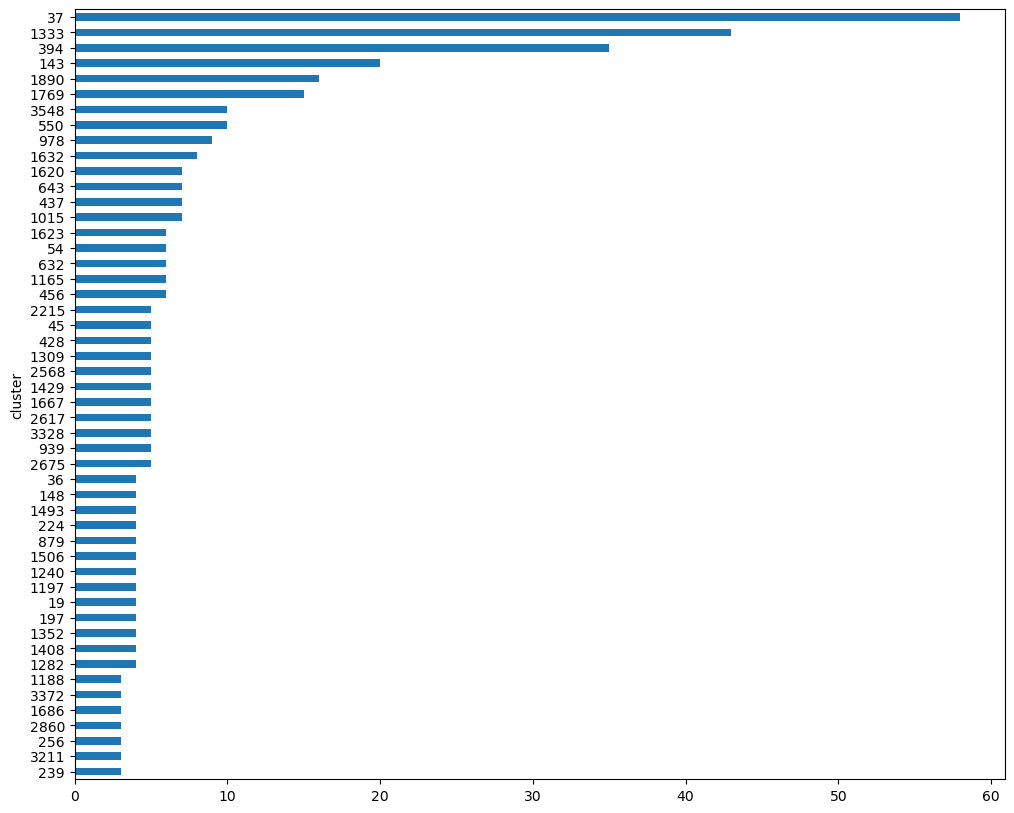

In [13]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [14]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([  37, 1333,  394, ..., 1275, 1276,   61], dtype=int64)

In [15]:
for cluster in top_clusters[0:20]:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(df[df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    #print(cluster_data)
    
    print()

cluster: 37

A 26-year-old Colombian father was killed in a shooting involving ICE in Maine.
A Colombian father of a 3-year-old was killed in a shooting in Maine.
A man was killed during an ICE shooting incident in Maine.
A report about an ICE shooting related to the Maine Senate.
A report on a shooting incident in Maine and its political implications.
A report on a shooting involving ICE during vehicle stops in Texas.
Coverage of a shooting incident in Maine.
Discussion of the impact of an ice shooting on the Maine Senate race.
Hundreds are protesting in Maine following a fatal shooting.
Hundreds are protesting in Maine following the fatal shooting of a Colombian man by ICE.
Hundreds are protesting in Maine over the fatal shooting of a Colombian man by ICE.
Hundreds protest over the fatal shooting of a Colombian man by ICE in Maine.
Hundreds rally in response to a fatal shooting.
Johan Sebastian Duran Guerrero is identified as the Colombian father of a 3-year-old who was killed in a s

In [16]:
def display_top_clusters(max_clusters=20, max_preview_rows=20, show_urls=False):

    top_clusters = df['cluster'].value_counts().index.values

    for cluster in top_clusters[0:max_clusters]:

        claim_count = len(df[df['cluster'] == cluster])
        print('cluster: {} ({} claims)\n'.format(cluster, claim_count))

        cluster_data = df[df['cluster'] == cluster].sort_values('date_added').head(max_preview_rows)

        for _, row in cluster_data.iterrows():
            dt_str = row['date_added'].strftime('%Y/%m/%d %H:%M:%S')
            print(f"{dt_str} - {row['claim']} ({row['domain']})")

        if show_urls:
            print("\nURLs:")
            for url in cluster_data['url'].tolist():
                print(url)

        print()


display_top_clusters(max_clusters=20, max_preview_rows=20)

cluster: 37 (58 claims)

2026/07/13 18:40:44 - Discussion about a shooting incident involving ICE in Maine and its implications (memeorandum.com)
2026/07/13 19:00:42 - Live news coverage of a shooting incident in Maine related to ice. (cnn.com)
2026/07/13 19:00:42 - A video covering protests related to the Maine shooting incident. (cnn.com)
2026/07/13 19:00:42 - A video related to the Maine ice shooting incident. (cnn.com)
2026/07/13 19:34:51 - Report on a shooting incident in Maine (newsnow.co.uk)
2026/07/13 19:42:37 - Report on a shooting involving ICE agents. (memeorandum.com)
2026/07/13 20:07:01 - A Colombian migrant was killed in an ICE shooting in Maine. (memeorandum.com)
2026/07/13 20:22:43 - Protests are escalating following the fatal shooting of a 26-year-old man by ICE in Maine. (endtimeheadlines.org)
2026/07/13 20:36:27 - A report on a shooting in Maine resulting in one death. (hotair.com)
2026/07/13 21:10:15 - Coverage of a shooting involving US ICE. (memeorandum.com)
2026/

2026/07/14 14:38:49 - The Trump administration has ordered ICE to suspend most vehicle stops following two deadly shootings. (infonews.ca)
2026/07/14 14:45:03 - The Trump administration is ordering ICE to suspend most vehicle stops following two deadly shootings. (wnyt.com)

cluster: 978 (9 claims)

2026/07/13 18:50:16 - An ICE agent fatally shoots a driver in Maine, occurring shortly after a similar incident in Texas. (detroitnews.com)
2026/07/13 20:50:18 - Conflict in Maine as ICE agent shoots at migrant (headtopics.com)
2026/07/13 20:50:18 - ICE agent shoots and injures a man in Biddeford, Maine (headtopics.com)
2026/07/13 22:39:17 - An ICE agent fatally shoots a motorist in Maine (headtopics.com)
2026/07/13 23:17:23 - An ICE agent fatally shot a Colombian man in the U.S. (headtopics.com)
2026/07/14 04:38:27 - ICE agent shoots driver in Maine (headtopics.com)
2026/07/14 06:00:20 - A fatal shooting involving ICE in Maine occurred just days after a similar incident. (headtopics.com)
2

In [17]:
display_top_clusters(max_clusters=100, max_preview_rows=20)

cluster: 37 (58 claims)

2026/07/13 18:40:44 - Discussion about a shooting incident involving ICE in Maine and its implications (memeorandum.com)
2026/07/13 19:00:42 - Live news coverage of a shooting incident in Maine related to ice. (cnn.com)
2026/07/13 19:00:42 - A video covering protests related to the Maine shooting incident. (cnn.com)
2026/07/13 19:00:42 - A video related to the Maine ice shooting incident. (cnn.com)
2026/07/13 19:34:51 - Report on a shooting incident in Maine (newsnow.co.uk)
2026/07/13 19:42:37 - Report on a shooting involving ICE agents. (memeorandum.com)
2026/07/13 20:07:01 - A Colombian migrant was killed in an ICE shooting in Maine. (memeorandum.com)
2026/07/13 20:22:43 - Protests are escalating following the fatal shooting of a 26-year-old man by ICE in Maine. (endtimeheadlines.org)
2026/07/13 20:36:27 - A report on a shooting in Maine resulting in one death. (hotair.com)
2026/07/13 21:10:15 - Coverage of a shooting involving US ICE. (memeorandum.com)
2026/

2026/07/13 21:46:28 - A boy is in critical condition after a stabbing incident at a school in Brisbane. (headtopics.com)
2026/07/13 22:39:17 - A teen is in a life-threatening condition after an incident at a school in Brisbane (headtopics.com)
2026/07/13 23:32:58 - A teenager is in critical condition after a stabbing incident at a Brisbane high school. (headtopics.com)
2026/07/14 00:26:57 - A teen is fighting for their life after a stabbing incident at a Brisbane school. (headtopics.com)
2026/07/14 09:34:57 - A cyclist is in critical condition after a crash with a vehicle. (headtopics.com)
2026/07/14 14:17:19 - A teenager has been charged following a stabbing incident at a school in Brisbane. (headtopics.com)

cluster: 1165 (6 claims)

2026/07/13 21:27:34 - Lettuce and salad greens could be the source of an outbreak in Michigan. (1190kex.iheart.com)
2026/07/14 10:46:13 - Health officials suggest that salad greens may be linked to cyclospora illnesses in Michigan. (abc7.com)
2026/07/14 

2026/07/14 01:32:31 - Tour dates for comedian Peter Kay (ents24.com)
2026/07/14 09:13:40 - Tour dates for comedian Russell Kane (ents24.com)
2026/07/14 11:20:56 - Tour dates for comedian Jason Manford (ents24.com)

cluster: 3372 (3 claims)

2026/07/13 19:56:01 - Video clip available on ABC7 News. (abc7news.com)
2026/07/13 19:56:01 - Video clip available on ABC7 News. (abc7news.com)
2026/07/13 19:56:01 - Video clip available on ABC7 News. (abc7news.com)

cluster: 1686 (3 claims)

2026/07/14 08:07:06 - News headline or report (headtopics.com)
2026/07/14 08:07:06 - News headline or report (headtopics.com)
2026/07/14 08:07:06 - News headline or report (headtopics.com)

cluster: 2860 (3 claims)

2026/07/13 20:28:45 - Bachelor in Paradise star Joe Amabile has a tumor that was discovered in his brain. (abcnews.go.com)
2026/07/13 23:20:49 - Bachelor in Paradise star Joe Amabile had a tumor discovered in his brain. (abc7.com)
2026/07/14 00:23:43 - A tumor was discovered in Bachelor in Paradise 

2026/07/14 02:05:55 - Report on Bill Belichick's daughter-in-law being arrested for a court appearance failure (news.ssbcrack.com)
2026/07/14 08:45:33 - Information on a warrant for the arrest of Bill Belichick's daughter-in-law. (the-independent.com)
2026/07/14 09:16:49 - Bill Belichick's daughter-in-law has an arrest order issued. (usatoday.com)

cluster: 1635 (3 claims)

2026/07/14 07:42:57 - An Air Force helicopter made an emergency landing in Washington, D.C. (noticias.foxnews.com)
2026/07/14 08:13:28 - An Air Force helicopter made an emergency landing in Washington, D.C. (foxnews.com)
2026/07/14 08:27:04 - A U.S. Air Force VIP helicopter made an emergency landing (thegatewaypundit.com)

cluster: 323 (3 claims)

2026/07/14 15:38:52 - Indictments reveal five inmate murders, assaults, and other crimes (headtopics.com)
2026/07/14 15:45:19 - Tennessee prison is experiencing a rise in murders and assaults. (apnews.com)
2026/07/14 16:11:14 - Indictments reveal multiple inmate murders an

In [18]:
# this really might be all we need for daily briefings
# the below stuff was from a previous analysis and a bit overkill for what I need
# this above function gives me what I need.

# Good Start

That's a good start, but I want to have three different classes of cluster sizes: A, B, C. A will be biggest, then B, then C will be small clusters.

Big clusters are what everyone is talking about. The big stories.
Medium clusters are stories that are less widely talked about than big clusters.
Small clusters are stories that are talked about by few sources.

In [266]:
# simpler than binning; just gets it done. :)

def classify_cluster(count):

    if count >= 8:
        return 'A'
    elif count >= 4:
        return 'B'
    else:
        return 'C'

In [267]:
cluster_df = pd.DataFrame(df['cluster'].value_counts()).reset_index()

cluster_df['class'] = cluster_df['count'].apply(classify_cluster)

cluster_df

,cluster,count,class
0,25,26,A
1,400,19,A
2,30,13,A
3,54,13,A
4,2890,13,A
...,...,...,...
3233,1149,1,C
3234,1150,1,C
3235,1151,1,C
3236,1152,1,C


In [268]:
cluster_df['count'].describe()

count    3238.000000
mean        1.169240
std         0.864509
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        26.000000
Name: count, dtype: float64

# Split into Class DFs

Now I want to split this into three DFs and loop through each one so that I can see different size clusters more easily.

In [269]:
class_a_df = cluster_df[cluster_df['class'] == 'A']
class_b_df = cluster_df[cluster_df['class'] == 'B']
class_c_df = cluster_df[cluster_df['class'] == 'C']

## Class A Clusters - Big Clusters; More Chatter

In [270]:
class_df = class_a_df
top_clusters = class_df['cluster'].values

subset_df = df[df['cluster'].isin(top_clusters)].copy()
subset_df['cluster'] = cluster_text(subset_df['claim'], similarity_threshold=0.4) # reducing to capture broader topics

top_clusters = subset_df['cluster'].value_counts().index.values
top_clusters

for cluster in top_clusters:
    
    print('cluster: {}\n'.format(cluster))
    
    cluster_data = sorted(subset_df[subset_df['cluster']==cluster].head(20)['claim'].values)
    for claim in cluster_data:
        print(claim)
    
    print()

cluster: 16

Information about the Douglaston area in New York
Information about the Laurelton area in New York
Information about the Manhattan area in New York
Information about the Massapequa area in New York
Information about the Middletown area in New Jersey
Information about the Mill Basin area in New York
Information about the Monticello area in New York
Information about the Oceanside area in New York
Information about the Ridgewood area in New York
Information about the St. Albans area in New York
Information about the White Lake area in New York
Information about the Woodhaven area in New York
Information about the Wyandanch area in New York

cluster: 1

Alaric Jackson of the Rams has been arrested for felony domestic battery
Alaric Jackson of the Rams has been arrested on suspicion of felony domestic violence.
Alaric Jackson of the Rams was arrested on a felony domestic violence charge.
Alaric Jackson, left tackle for the LA Rams, has been arrested on suspicion of a crime.
Ra

In [271]:
def display_clusters(class_df, similarity_threshold=0.5, max_preview_rows=20, show_urls=False):
    
    top_clusters = class_df['cluster'].values
    subset_df = df[df['cluster'].isin(top_clusters)].copy()
    subset_df['cluster'] = cluster_text(subset_df['claim'], similarity_threshold=similarity_threshold)
    top_clusters = subset_df['cluster'].value_counts().index.values
    
    for cluster in top_clusters:
        
        claim_count = len(subset_df[subset_df['cluster'] == cluster])
        print('cluster: {} ({} claims)\n'.format(cluster, claim_count))
        cluster_data = subset_df[subset_df['cluster'] == cluster].sort_values('date_added').head(max_preview_rows)
        for _, row in cluster_data.iterrows():
            dt_str = row['date_added'].strftime('%Y/%m/%d %H:%M:%S')
            print(f"{dt_str} - {row['claim']} ({row['domain']})")

        if show_urls:
            print("\nURLs:")
            for url in cluster_data['url'].tolist():
                print(url)

        print()

In [272]:
display_clusters(class_a_df)

cluster: 47 (12 claims)

2026/06/08 17:33:05 - Information about the Monticello area in New York (fillmore.com)
2026/06/08 17:33:05 - Information about the Woodhaven area in New York (fillmore.com)
2026/06/08 17:33:05 - Information about the White Lake area in New York (fillmore.com)
2026/06/08 17:33:05 - Information about the St. Albans area in New York (fillmore.com)
2026/06/08 17:33:05 - Information about the Ridgewood area in New York (fillmore.com)
2026/06/08 17:33:05 - Information about the Oceanside area in New York (fillmore.com)
2026/06/08 17:33:05 - Information about the Massapequa area in New York (fillmore.com)
2026/06/08 17:33:05 - Information about the Mill Basin area in New York (fillmore.com)
2026/06/08 17:33:05 - Information about the Manhattan area in New York (fillmore.com)
2026/06/08 17:33:05 - Information about the Laurelton area in New York (fillmore.com)
2026/06/08 17:33:05 - Information about the Douglaston area in New York (fillmore.com)
2026/06/08 17:33:05 - I

2026/06/08 21:27:24 - Koe Wetzel is performing in Del Mar on June 12, 2026, at 7:30 PM. (san-diego.events)

cluster: 19 (1 claims)

2026/06/09 03:55:59 - Rob Reiner's son accused of stabbing his parents. (headtopics.com)

cluster: 20 (1 claims)

2026/06/09 03:39:46 - Man arrested for a brutal knife attack in Northern Ireland (straitstimes.com)

cluster: 22 (1 claims)

2026/06/09 03:25:51 - Ariana Grande is scheduled to perform in Oakland on June 10, 2026, at 8:00 PM. (san-francisco.events)

cluster: 23 (1 claims)

2026/06/09 02:42:17 - A knife attack occurred in Belfast. (independent.co.uk)

cluster: 24 (1 claims)

2026/06/09 02:39:46 - A man has been arrested following a knife attack in Belfast. (dailyrecord.co.uk)

cluster: 44 (1 claims)

2026/06/08 19:22:44 - Asif Ali is performing in La Jolla on June 12, 2026, at 7:00 PM (san-diego.events)

cluster: 30 (1 claims)

2026/06/08 21:00:39 - Ethan Buckner is performing in West Hollywood on June 10, 2026, at 7:00 PM. (los-angeles.events)


## Class B Clusters - Average Sized Clusters;

In [273]:
display_clusters(class_b_df)

cluster: 55 (7 claims)

2026/06/08 23:48:04 - A setlist for a performance at Brash Brewing in Houston, TX. (setlist.fm)
2026/06/08 23:48:04 - A setlist for a performance by Fromjoy at Brash Brewing in Houston, TX. (setlist.fm)
2026/06/08 23:48:04 - A setlist for a performance by Means of Destruction at Brash Brewing in Houston, TX. (setlist.fm)
2026/06/08 23:48:04 - A setlist for a performance by Sabella at Brash Brewing in Houston, TX. (setlist.fm)
2026/06/08 23:48:04 - A setlist for a performance by Thus Spoke Zarathustra at Brash Brewing in Houston, TX. (setlist.fm)
2026/06/09 00:28:47 - Setlist for the 'Girl of Glass' performance at Brash Brewing in Houston, TX. (setlist.fm)
2026/06/09 00:28:47 - Setlist for the 'Our Eyes Go Blank Tonight' performance at Brash Brewing in Houston, TX. (setlist.fm)

cluster: 23 (7 claims)

2026/06/08 17:59:48 - More than 1 million Jeep vehicles are recalled due to a fire risk, with warnings for owners not to park inside. (foxnews.com)
2026/06/08 19:3

2026/06/09 03:55:59 - Japanese city captures bear that caused fear and school closures. (infonews.ca)
2026/06/09 07:17:37 - Japanese city captures bear that caused fear and school closures. (headtopics.com)
2026/06/09 08:23:02 - A Japanese city captures a bear that caused fear among residents and schools. (headtopics.com)

cluster: 26 (3 claims)

2026/06/09 05:49:14 - A Japanese city captured a bear that was causing fear and led to school closures. (ksl.com)
2026/06/09 09:30:04 - A bear has been captured in a Japanese city after causing fear and leading to school closures. (10news.com)
2026/06/09 10:51:18 - A bear was captured in a Japanese city after causing fear and school closures (apnews.com)

cluster: 37 (3 claims)

2026/06/09 03:21:08 - Knicks watch party at Bryant Park ends with 7 arrests (headtopics.com)
2026/06/09 08:00:03 - Arrests made at Knicks watch party (newsday.com)
2026/06/09 08:55:44 - Reports on the arrests made during a Knicks watch party at Bryant Park. (danspapers

## Class C Clusters - Small Stories; Less Chatter

In [274]:
display_clusters(class_c_df)

cluster: 2757 (3 claims)

2026/06/08 20:39:33 - An illegal alien was convicted of raping a 13-year-old girl in Florida. (breitbart.com)
2026/06/08 20:39:33 - An illegal alien was convicted of raping a 13-year-old girl in Florida. (breitbart.com)
2026/06/08 21:01:39 - An illegal alien was convicted of raping a young girl in Palm Beach County, Florida. (breitbart.com)

cluster: 2623 (3 claims)

2026/06/08 21:53:25 - Wiz Khalifa is performing at PNC Bank Arts Center. (bandsintown.com)
2026/06/08 22:55:44 - De'Wayne is performing at PNC Bank Arts Center. (bandsintown.com)
2026/06/09 06:28:34 - Machine Gun Kelly is performing at PNC Bank Arts Center (bandsintown.com)

cluster: 2969 (3 claims)

2026/06/08 15:56:00 - Telehealth access to the abortion pill is lifesaving for domestic violence survivors, according to some sources. (idahocapitalsun.com)
2026/06/08 18:44:13 - Claim: Telehealth access to abortion pill is vital for domestic violence survivors (wisconsinexaminer.com)
2026/06/09 04:46

2026/06/09 09:47:03 - A McDonald's worker suffered severe burns allegedly caused by a coworker throwing hot oil. (abc7.com)
2026/06/09 10:57:47 - A McDonald's worker allegedly caused severe burns by throwing hot oil. (abc7chicago.com)

cluster: 1664 (2 claims)

2026/06/09 06:12:42 - Bonnie Raitt is performing at the Elsinore Theatre. (bandsintown.com/c/hillsboro-or)
2026/06/09 14:20:41 - Maia Sharp is performing at the Elsinore Theatre. (bandsintown.com/c/beaverton-or)

cluster: 796 (2 claims)

2026/06/09 10:42:15 - Alex Lahey is performing at Cafe du Nord. (allevents.in/san%20francisco/poetry)
2026/06/09 10:57:08 - Performance by Chxrry at Cafe du Nord (allevents.in/san%20francisco/poetry)

cluster: 1447 (2 claims)

2026/06/08 15:25:13 - Molly Mae Hague shares an intimate photo of breastfeeding her newborn. (headtopics.com)
2026/06/08 18:04:59 - Molly Mae Hague shares family photos while breastfeeding her newborn. (dailymail.co.uk)

cluster: 1060 (2 claims)

2026/06/09 08:58:57 - Cris

2026/06/09 04:40:20 - A Moroccan individual has been arrested for the anal rape of an autistic minor in a kebab shop's bathroom in Spain. (whatfinger.com)
2026/06/09 07:31:48 - A Moroccan immigrant was arrested for the anal rape of an autistic minor in a kebab shop bathroom. (rense.com)

cluster: 236 (2 claims)

2026/06/08 15:47:49 - An Auburn student, reported missing in Japan, was found deceased in a decomposed state. (flipboard.com)
2026/06/08 19:44:45 - An Auburn student went missing in Japan and was later found deceased. (flipboard.com)

cluster: 3268 (2 claims)

2026/06/08 16:40:41 - Danny Daze is performing at Knockdown Center. (bandsintown.com)
2026/06/08 16:40:41 - L'Rain is performing at Knockdown Center. (bandsintown.com)

cluster: 3015 (2 claims)

2026/06/08 18:18:06 - Kenya's former chief justice David Maraga was arrested while protesting against national park construction. (infonews.ca)
2026/06/09 00:14:37 - Former Chief Justice David Maraga arrested during a protest (hea

2026/06/08 21:40:04 - An inmate has died at Santa Rita Jail. (eastbaytimes.com)
2026/06/08 21:41:19 - An inmate at Santa Rita Jail has died. (mercurynews.com)

cluster: 1824 (2 claims)

2026/06/09 05:02:11 - A father has been arrested on suspicion of killing his son. (eastbaytimes.com)
2026/06/09 05:05:22 - Father arrested on suspicion of killing his son (mercurynews.com)

cluster: 971 (2 claims)

2026/06/08 18:56:00 - Sawyer Hill is scheduled to perform a concert. (casbahmusic.com)
2026/06/09 09:58:22 - Kacie Hill is scheduled to perform at Purgatory. (bandsintown.com)

cluster: 2560 (2 claims)

2026/06/08 22:30:28 - A federal trial is beginning for an Idaho doctor who is seeking medical exemptions to an abortion ban. (idahocapitalsun.com)
2026/06/09 12:21:23 - A federal trial has commenced for an Idaho doctor pursuing medical exemptions in relation to an abortion ban. (washingtonstatestandard.com)

cluster: 1532 (2 claims)

2026/06/09 07:04:22 - A controlling husband is accused of ra

2026/06/09 01:52:06 - Molly Mae Hague shares moment she learned baby's gender (headtopics.com)

cluster: 2342 (1 claims)

2026/06/09 00:56:53 - Police investigation following a shooting in Copenhagen (headtopics.com)

cluster: 2235 (1 claims)

2026/06/09 01:52:06 - Portugal at risk of wildfire and UV exposure (headtopics.com)

cluster: 2236 (1 claims)

2026/06/09 01:52:06 - Immigrant from Georgia dies in detention center in the US (headtopics.com)

cluster: 2341 (1 claims)

2026/06/09 00:56:53 - Discovery of a house where surgeries were performed (headtopics.com)

cluster: 2239 (1 claims)

2026/06/09 01:52:06 - Brothers deny dangerous driving causing death (headtopics.com)

cluster: 2340 (1 claims)

2026/06/09 00:56:53 - Allegations of sexual assault against Patrick Bruel (headtopics.com)

cluster: 2339 (1 claims)

2026/06/09 00:56:53 - Koeman's personal situation regarding his sick wife (headtopics.com)

cluster: 2277 (1 claims)

2026/06/09 01:45:15 - Tips for keeping yourself and you

...

2026/06/09 09:42:41 - Maeve is scheduled to perform at The Cock and Tail in Bristol, England in 2026 (setlist.fm)

cluster: 1042 (1 claims)

2026/06/09 09:42:41 - Orchestre de l'Opéra National de Paris is scheduled to perform at Opera Bastille in Paris, France in 2025 (setlist.fm)

cluster: 1043 (1 claims)

2026/06/09 09:42:41 - Owsley’s Owls is scheduled to perform at Midway Cafe in Boston, MA in 2026 (setlist.fm)

cluster: 1044 (1 claims)

2026/06/09 09:42:41 - Scandal is scheduled to perform at EX Theatre Roppongi in Tokyo, Japan in 2026 (setlist.fm)

cluster: 1045 (1 claims)

2026/06/09 09:42:41 - The Dare is scheduled to perform at Flushing Meadows Corona Park in Queens, NY in 2026 (setlist.fm)

cluster: 1046 (1 claims)

2026/06/09 09:42:41 - The Fab Four performed at The Moore Theatre in Seattle, WA in 2022 (setlist.fm)

cluster: 1047 (1 claims)

2026/06/09 09:42:41 - Asspera is scheduled to perform at C Complejo Art Media in Buenos Aires, Argentina in 2026 (setlist.fm)

cluster:

cluster: 924 (1 claims)

2026/06/09 10:12:02 - Questions arise as family of Lily Hernandez searches for answers (newsantaana.com)

cluster: 925 (1 claims)

2026/06/09 10:12:00 - Migrant crisis linked to gang offender on the run after guilty verdict (gbnews.com)

cluster: 926 (1 claims)

2026/06/09 10:11:53 - 21 arrests made after clashes with New York police (abcnews.go.com)

cluster: 927 (1 claims)

2026/06/09 10:10:08 - Protests regarding the jailing of individuals involved in a crime in Southampton (independent.co.uk)

cluster: 928 (1 claims)

2026/06/09 10:09:12 - The 25th edition of a literature festival will feature guests such as Emmanuel Carrère, Zerocalcare, and Ahmet Altan at Stadio Palatino. (roma.corriere.it)

cluster: 929 (1 claims)

2026/06/09 10:09:06 - A shark attack in Panama City resulted in one person being hospitalized. (foxnews.com)

cluster: 930 (1 claims)

2026/06/09 10:08:40 - Hundreds of people are lining up to fill their tanks for $1.99 at a Shell station in H

cluster: 947 (1 claims)

2026/06/09 10:03:09 - A hero in Belfast identified who stopped a beheading attempt. (memeorandum.com)

cluster: 948 (1 claims)

2026/06/09 10:02:38 - A father in San Jacinto shot and killed an armed intruder. (freerepublic.com)

cluster: 950 (1 claims)

2026/06/09 10:01:51 - The jury is set to decide whether a stabbing at a Texas track meet was murder or self-defense. (ktvz.com)

cluster: 963 (1 claims)

2026/06/09 09:58:26 - A man accused of killing Iryna Zarutska has been ruled incompetent to stand trial. (justthenews.com)

cluster: 951 (1 claims)

2026/06/09 10:01:51 - Reported news about a stabbing incident involving Pouria Zeraati in London. (independent.co.uk)

cluster: 952 (1 claims)

2026/06/09 10:01:51 - News coverage about Sarah Kellen being identified as a victim of Epstein. (independent.co.uk)

cluster: 953 (1 claims)

2026/06/09 10:01:07 - A man was shot to death after confronting a teen about loud phone talk on a bus. (thelibertydaily.com)

cluste

2026/06/09 08:23:02 - Teens are being recruited by crime syndicates for arson attacks. (headtopics.com)

cluster: 1300 (1 claims)

2026/06/09 08:23:02 - A new aggression occurs in Nivelles prison involving a detainee. (headtopics.com)

cluster: 1301 (1 claims)

2026/06/09 08:23:02 - A former childcare provider is convicted for her actions. (headtopics.com)

cluster: 1302 (1 claims)

2026/06/09 08:23:02 - A crime podcast investigates the death of a jogger and a dog owner. (headtopics.com)

cluster: 1303 (1 claims)

2026/06/09 08:23:02 - The video shows a private jet that exploded upon landing in the Republic. (headtopics.com)

cluster: 1304 (1 claims)

2026/06/09 08:23:02 - A car manufacturer recalls more than a million vehicles due to fears of safety. (headtopics.com)

cluster: 1305 (1 claims)

2026/06/09 08:23:02 - The market threatens nursing homes with competition. (headtopics.com)

cluster: 1306 (1 claims)

2026/06/09 08:23:02 - At least nine dead and 29 injured from Israeli attack

cluster: 1118 (1 claims)

2026/06/09 09:06:37 - For Gen Z, work-life balance is the top career goal. (headtopics.com)

cluster: 1119 (1 claims)

2026/06/09 09:06:37 - A single mother dies in a collision between a motorcycle and a car. (headtopics.com)

cluster: 1120 (1 claims)

2026/06/09 09:06:37 - The Inspector General of Police has redeployed officers to address rising issues across regions. (headtopics.com)

cluster: 1121 (1 claims)

2026/06/09 09:06:37 - Nigerian youth march to the National Assembly to protest against insecurity. (headtopics.com)

cluster: 1122 (1 claims)

2026/06/09 09:06:37 - The state where single mothers are counted as poor. (headtopics.com)

cluster: 1123 (1 claims)

2026/06/09 09:06:37 - Emotional healing and self-love: how to overcome traumas and avoid future issues. (headtopics.com)

cluster: 1124 (1 claims)

2026/06/09 09:06:37 - Divorces, new loves, and family conflicts in the plot. (headtopics.com)

cluster: 1125 (1 claims)

2026/06/09 09:06:37 - Reside

In [275]:
# All paying readers who have API access can do this.
# If you do not have API access and would like to pay for it, email me at info@verdantintel.com